# Trade-size distribution

Load every swap, value each in USD via a **causal** (past-only) trailing-hour average of the
Kraken CEX price, and build the pooled trade-size distribution. Its quantiles are the
reference trade sizes used by `arbitrage_index.ipynb`. Parameters come from `arblib.config.STUDY`.

In [1]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, sizing, preprocessing, plotting
from arblib.config import STUDY as S

dfs = data_io.load_pool_csvs(S.swaps_dir)
swaps = sizing.pooled_swaps(dfs)
x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)

Loaded: df_uniswap_swap.csv
       amount0               amount1         dex  evt_block_number  \
0   -999266400    334197952309227723  uniswap_v3          24133363   
1     33925490    -11345521500000000  uniswap_v4          24133364   
2  13936469654  -4658615254546375464  uniswap_v3          24133365   
3   -107703773     36025562985474874  uniswap_v3          24133365   
4   -154244910     51582178535019641  uniswap_v4          24133365   

                evt_block_time  evt_index  \
0  2025-12-31 15:00:11.000 UTC         17   
1  2025-12-31 15:00:23.000 UTC          3   
2  2025-12-31 15:00:35.000 UTC        353   
3  2025-12-31 15:00:35.000 UTC         40   
4  2025-12-31 15:00:35.000 UTC        719   

                                         evt_tx_hash  fee  \
0  0x045ccf214364711f41a1e4ebdc460703fb1d3f6ccfae...  100   
1  0x7e40441f67a6ffeb29115fdf3028481faf2a2b9772bf...    0   
2  0xa8e2974554c1b06a7ab79cf43f0764f29ea521b0e1e6...  500   
3  0xa0671b25449576f08044498e74206b1

## 1. Verify token identity ↔ decimals

In [2]:
preprocessing.verify_token_decimals(swaps, S.token0, S.token1)

0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 -> 6 decimals
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 -> 18 decimals

OK: token0 (6 dp), token1 (18 dp) consistent across all pools.


## 2. Human + USD amounts

In [3]:
swaps = sizing.add_usd_amounts(swaps, x_usd, y_usd, S.cex_avg_window_min)
swaps[["time", "x_rate", "y_rate", "amount0_h", "amount0_usd", "amount1_h", "amount1_usd"]].head()

,time,x_rate,y_rate,amount0_h,amount0_usd,amount1_h,amount1_usd
0,2025-12-31 15:00:11+00:00,0.99964,2998.8875,-999.266400,-998.906664,0.334198,1002.222062
1,2025-12-31 15:00:23+00:00,0.99964,2998.8875,33.925490,33.913277,-0.011346,-34.023943
2,2025-12-31 15:00:35+00:00,0.99964,2998.8875,-113.077566,-113.036858,0.037844,113.489978
3,2025-12-31 15:00:35+00:00,0.99964,2998.8875,-154.244910,-154.189382,0.051582,154.689150
4,2025-12-31 15:00:35+00:00,0.99964,2998.8875,-48.951314,-48.933692,0.016370,49.092814


## 3. Split by direction (the in-leg of each swap)

In [4]:
x_in, y_in = sizing.split_in_legs(swaps)

Kept 1272 of 1306 swaps after dust filter
token0-in: 657 swaps | token1-in: 615 swaps


## 4. Trade-size distributions (per leg)

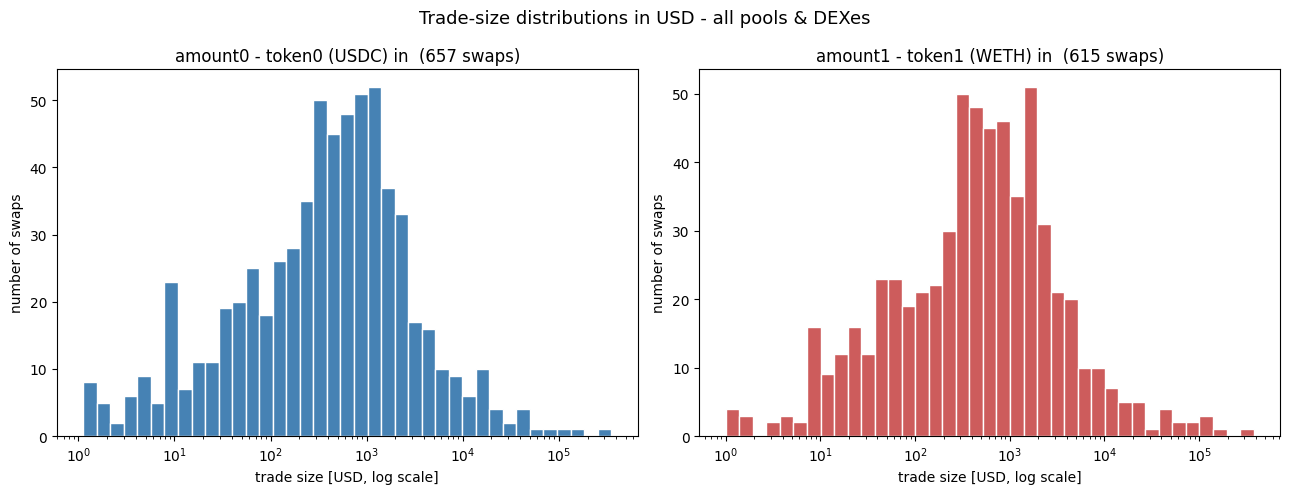

In [5]:
plotting.plot_trade_size_distributions(x_in, y_in, S.token0.symbol, S.token1.symbol)

## 5. Global distribution & reference quantiles

0.2      63.250927
0.4     313.051119
0.6     739.827726
0.8    1858.485446
dtype: float64


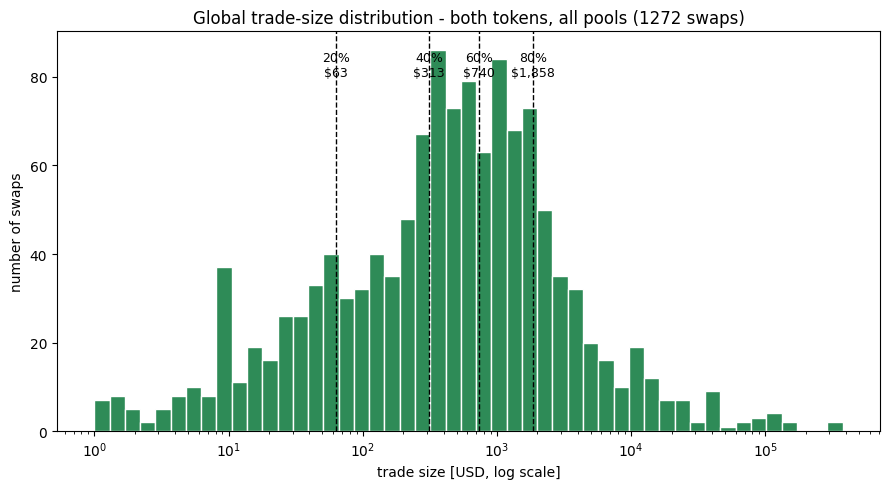

In [6]:
trade_sizes = sizing.pooled_trade_sizes(x_in, y_in)
quantiles = sizing.trade_size_quantiles(trade_sizes, list(S.reference_quantiles))
print(quantiles)
plotting.plot_global_trade_size(trade_sizes, quantiles)

## 6. Save the reference trade sizes

In [7]:
data_io.save_quantiles(quantiles, S.quantiles_path)

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/trade_size_quantiles.csv
